In [1]:
import folium

# Pusat peta di tengah area AOI
lat_c = (-7.1927923 + -7.1514786) / 2
lon_c = (112.6193968 + 112.6600158) / 2

m = folium.Map(location=[lat_c, lon_c], zoom_start=12)

# Tandai area polygon AOI Kabupaten Gresik
folium.Rectangle(
    bounds=[[-7.1927923, 112.6193968], [-7.1514786, 112.6600158]],
    color="red",
    fill=True,
    fill_opacity=0.2,
    tooltip="Area Kabupaten Gresik",
).add_to(m)

m

In [2]:
import pandas as pd

# Menampilkan 5 data teratas CSV CH4
df_ch4 = pd.read_csv("./../data/csv/CH4_gresik_timeseries.csv")
df_ch4.head()

,date,CH4
0,2025-08-24,NaN
1,2025-08-25,1867.289429
2,2025-08-26,NaN
3,2025-08-27,NaN
4,2025-08-28,NaN


In [3]:
import pandas as pd

# Menampilkan 5 data teratas CSV CO
df_co = pd.read_csv("./../data/csv/CO_gresik_timeseries.csv")
df_co.head()

,date,CO
0,2025-08-24,0.037918
1,2025-08-25,0.028240
2,2025-08-26,NaN
3,2025-08-27,0.034187
4,2025-08-28,0.027450


In [4]:
import pandas as pd

# Menampilkan 5 data teratas CSV NO2
df_no2 = pd.read_csv("./../data/csv/NO2_gresik_timeseries.csv")
df_no2.head()

,date,NO2
0,2025-08-24,0.000096
1,2025-08-25,0.000046
2,2025-08-26,0.000068
3,2025-08-27,NaN
4,2025-08-28,0.000060


In [5]:
import pandas as pd

# Menampilkan 5 data teratas CSV SO2
df_so2 = pd.read_csv("./../data/csv/SO2_gresik_timeseries.csv")
df_so2.head()

,date,SO2
0,2025-08-24,0.000347
1,2025-08-25,0.000817
2,2025-08-26,-0.000799
3,2025-08-27,-0.000513
4,2025-08-28,0.000327


In [6]:
import pandas as pd

# Menampilkan 5 data teratas CSV gabungan 4 polutan
df_polutan = pd.read_csv("./../data/csv/polutan_gresik.csv")
df_polutan.head()

,date,CH4,CO,NO2,SO2
0,2025-08-24,NaN,0.037918,0.000096,0.000347
1,2025-08-25,1867.289429,0.028240,0.000046,0.000817
2,2025-08-26,NaN,NaN,0.000068,-0.000799
3,2025-08-27,NaN,0.034187,NaN,-0.000513
4,2025-08-28,NaN,0.027450,0.000060,0.000327


In [7]:
import pandas as pd
df = pd.read_csv("../data/csv/CH4_gresik_timeseries.csv")
ch4 = df["CH4"]
missingValueCH4 = ch4.isna().sum()
validValueCH4 = ch4.notna().sum()
print(f"Jumlah missing value pada data ch4 : {missingValueCH4}")
print(f"Jumlah data terisi (valid) pada data ch4 : {validValueCH4}")

Jumlah missing value pada data ch4 : 335
Jumlah data terisi (valid) pada data ch4 : 31


In [8]:
df = pd.read_csv("../data/csv/CO_gresik_timeseries.csv")
co = df["CO"]
missingValueCO = co.isna().sum()
validValueCO = co.notna().sum()
print(f"Jumlah missing value pada data co : {missingValueCO}")
print(f"Jumlah data terisi (valid) pada data co : {validValueCO}")

Jumlah missing value pada data co : 157
Jumlah data terisi (valid) pada data co : 209


In [9]:
df = pd.read_csv("../data/csv/NO2_gresik_timeseries.csv")
no2 = df["NO2"]
missingValueNO2 = no2.isna().sum()
validValueNO2 = no2.notna().sum()
print(f"Jumlah missing value pada data no2 : {missingValueNO2}")
print(f"Jumlah data terisi (valid) pada data no2 : {validValueNO2}")

Jumlah missing value pada data no2 : 179
Jumlah data terisi (valid) pada data no2 : 187


In [10]:
df = pd.read_csv("../data/csv/SO2_gresik_timeseries.csv")
so2 = df["SO2"]
missingValueSO2 = so2.isna().sum()
validValueSO2 = so2.notna().sum()
print(f"Jumlah missing value pada data so2 : {missingValueSO2}")
print(f"Jumlah data terisi (valid) pada data so2 : {validValueSO2}")

Jumlah missing value pada data so2 : 144
Jumlah data terisi (valid) pada data so2 : 222


Jumlah outlier pada data ch4 : 2
Jumlah tidak outlier (normal) pada data ch4 : 29


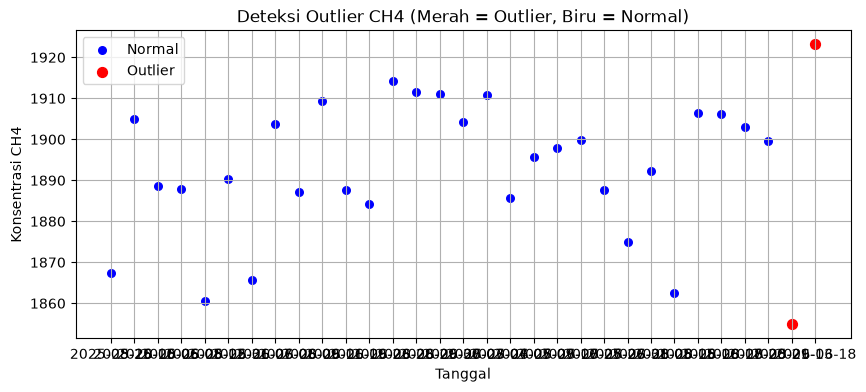

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/CH4_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CH4']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['CH4']])

normal_ch4 = df_clean[df_clean['outlier'] == 1]
outliers_ch4 = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data ch4 : {len(outliers_ch4)}")
print(f"Jumlah tidak outlier (normal) pada data ch4 : {len(normal_ch4)}")

# Visualisasi Grafik Outlier CH4
df_clean['date'] = pd.to_datetime(df_clean['date'])

plt.figure(figsize=(10, 4))
plt.scatter(normal_ch4['date'], normal_ch4['CH4'], color='blue', label='Normal', s=30)
plt.scatter(outliers_ch4['date'], outliers_ch4['CH4'], color='red', label='Outlier', s=50)
plt.title('Deteksi Outlier CH4 (Merah = Outlier, Biru = Normal)')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi CH4')
plt.legend()
plt.grid(True)
plt.show()

Jumlah outlier pada data co : 11
Jumlah tidak outlier (normal) pada data co : 198


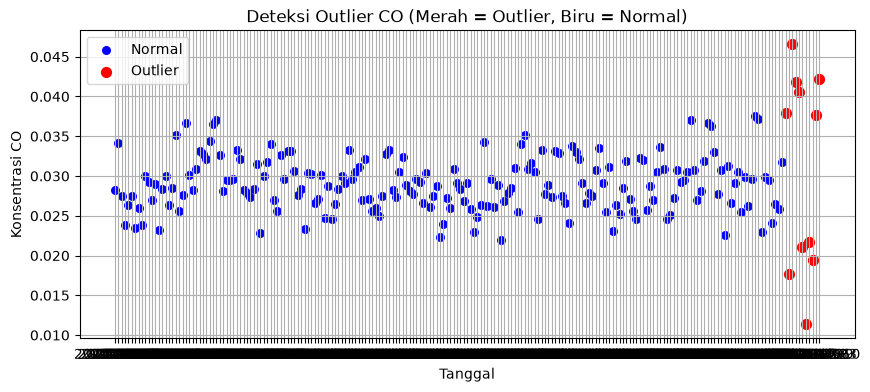

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/CO_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CO']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['CO']])

normal_co = df_clean[df_clean['outlier'] == 1]
outliers_co = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data co : {len(outliers_co)}")
print(f"Jumlah tidak outlier (normal) pada data co : {len(normal_co)}")

# Visualisasi Grafik Outlier CO
df_clean['date'] = pd.to_datetime(df_clean['date'])

plt.figure(figsize=(10, 4))
plt.scatter(normal_co['date'], normal_co['CO'], color='blue', label='Normal', s=30)
plt.scatter(outliers_co['date'], outliers_co['CO'], color='red', label='Outlier', s=50)
plt.title('Deteksi Outlier CO (Merah = Outlier, Biru = Normal)')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi CO')
plt.legend()
plt.grid(True)
plt.show()

Jumlah outlier pada data no2 : 10
Jumlah tidak outlier (normal) pada data no2 : 177


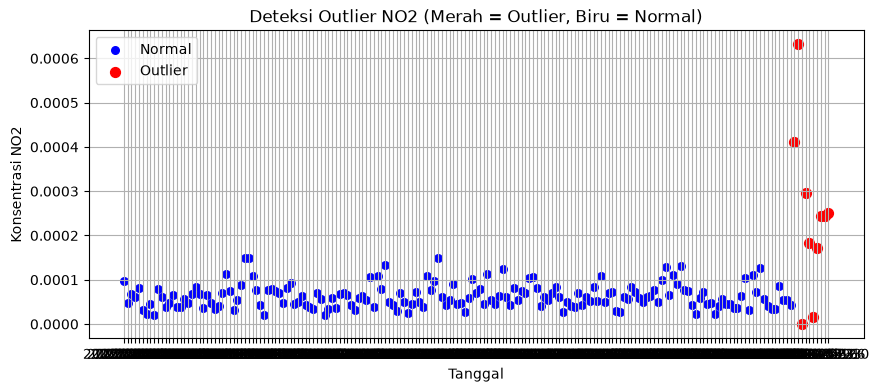

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/NO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['NO2']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['NO2']])

normal_no2 = df_clean[df_clean['outlier'] == 1]
outliers_no2 = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data no2 : {len(outliers_no2)}")
print(f"Jumlah tidak outlier (normal) pada data no2 : {len(normal_no2)}")

# Visualisasi Grafik Outlier NO2
df_clean['date'] = pd.to_datetime(df_clean['date'])

plt.figure(figsize=(10, 4))
plt.scatter(normal_no2['date'], normal_no2['NO2'], color='blue', label='Normal', s=30)
plt.scatter(outliers_no2['date'], outliers_no2['NO2'], color='red', label='Outlier', s=50)
plt.title('Deteksi Outlier NO2 (Merah = Outlier, Biru = Normal)')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi NO2')
plt.legend()
plt.grid(True)
plt.show()

Jumlah outlier pada data so2 : 12
Jumlah tidak outlier (normal) pada data so2 : 210


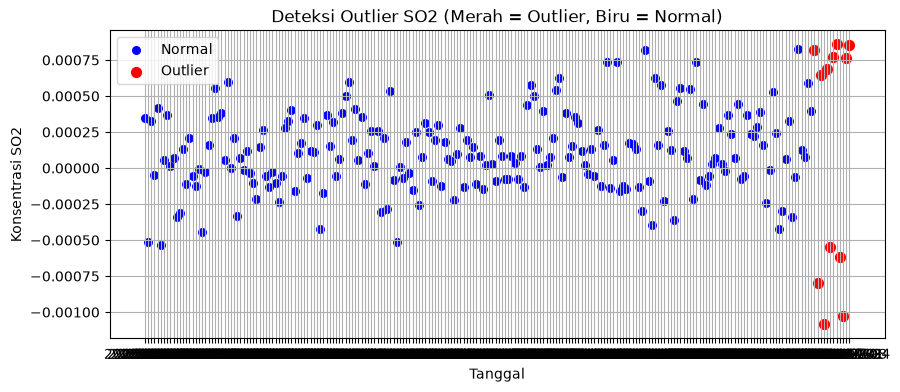

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/SO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['SO2']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['SO2']])

normal_so2 = df_clean[df_clean['outlier'] == 1]
outliers_so2 = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data so2 : {len(outliers_so2)}")
print(f"Jumlah tidak outlier (normal) pada data so2 : {len(normal_so2)}")

# Visualisasi Grafik Outlier SO2
df_clean['date'] = pd.to_datetime(df_clean['date'])

plt.figure(figsize=(10, 4))
plt.scatter(normal_so2['date'], normal_so2['SO2'], color='blue', label='Normal', s=30)
plt.scatter(outliers_so2['date'], outliers_so2['SO2'], color='red', label='Outlier', s=50)
plt.title('Deteksi Outlier SO2 (Merah = Outlier, Biru = Normal)')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi SO2')
plt.legend()
plt.grid(True)
plt.show()

Rata-rata CH4 : 1892.8467
Standar Deviasi CH4 : 17.3635
Koefisien Variasi (CV) CH4 : 0.92%


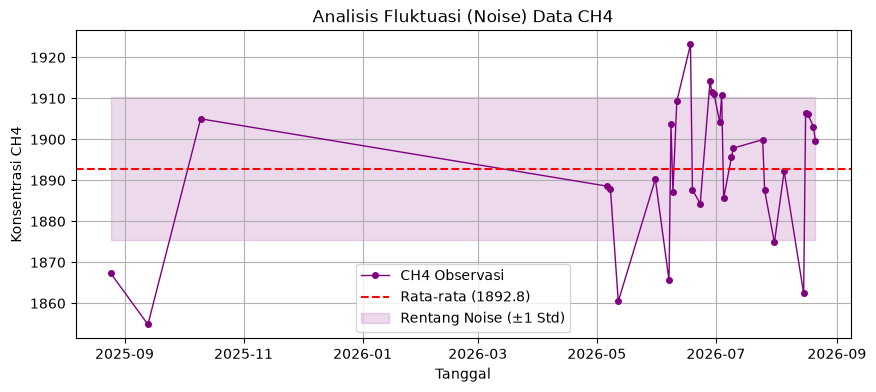

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/csv/CH4_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CH4']).copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])

mean_val = df_clean['CH4'].mean()
std_val = df_clean['CH4'].std()
cv_val = (std_val / mean_val) * 100

print(f"Rata-rata CH4 : {mean_val:.4f}")
print(f"Standar Deviasi CH4 : {std_val:.4f}")
print(f"Koefisien Variasi (CV) CH4 : {cv_val:.2f}%")

# Visualisasi Fluktuasi / Noise Data CH4
plt.figure(figsize=(10, 4))
plt.plot(df_clean['date'], df_clean['CH4'], marker='o', color='purple', linewidth=1, markersize=4, label='CH4 Observasi')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Rata-rata ({mean_val:.1f})')
plt.fill_between(df_clean['date'], mean_val - std_val, mean_val + std_val, color='purple', alpha=0.15, label=f'Rentang Noise (±1 Std)')
plt.title('Analisis Fluktuasi (Noise) Data CH4')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi CH4')
plt.legend()
plt.grid(True)
plt.show()

Rata-rata CO : 0.029098
Standar Deviasi CO : 0.004264
Koefisien Variasi (CV) CO : 14.66%


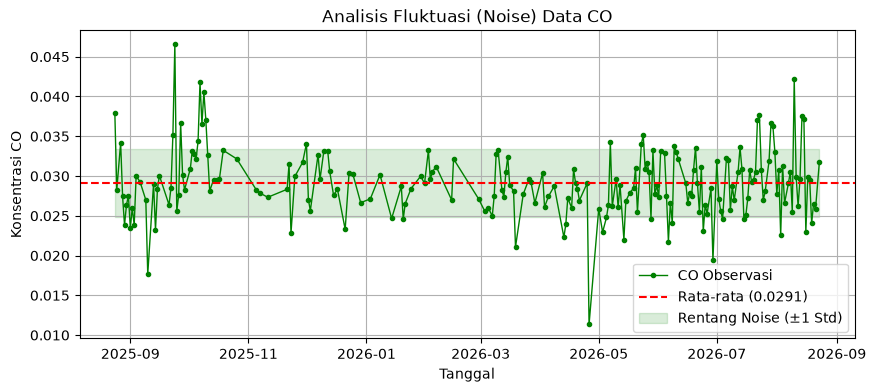

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/csv/CO_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CO']).copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])

mean_val = df_clean['CO'].mean()
std_val = df_clean['CO'].std()
cv_val = (std_val / mean_val) * 100

print(f"Rata-rata CO : {mean_val:.6f}")
print(f"Standar Deviasi CO : {std_val:.6f}")
print(f"Koefisien Variasi (CV) CO : {cv_val:.2f}%")

# Visualisasi Fluktuasi / Noise Data CO
plt.figure(figsize=(10, 4))
plt.plot(df_clean['date'], df_clean['CO'], marker='o', color='green', linewidth=1, markersize=3, label='CO Observasi')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Rata-rata ({mean_val:.4f})')
plt.fill_between(df_clean['date'], mean_val - std_val, mean_val + std_val, color='green', alpha=0.15, label=f'Rentang Noise (±1 Std)')
plt.title('Analisis Fluktuasi (Noise) Data CO')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi CO')
plt.legend()
plt.grid(True)
plt.show()

Rata-rata NO2 : 0.000073
Standar Deviasi NO2 : 0.000063
Koefisien Variasi (CV) NO2 : 86.60%


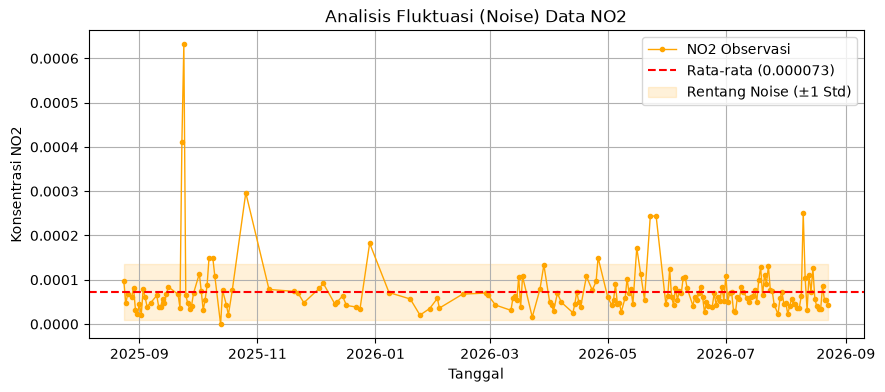

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/csv/NO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['NO2']).copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])

mean_val = df_clean['NO2'].mean()
std_val = df_clean['NO2'].std()
cv_val = (std_val / mean_val) * 100

print(f"Rata-rata NO2 : {mean_val:.6f}")
print(f"Standar Deviasi NO2 : {std_val:.6f}")
print(f"Koefisien Variasi (CV) NO2 : {cv_val:.2f}%")

# Visualisasi Fluktuasi / Noise Data NO2
plt.figure(figsize=(10, 4))
plt.plot(df_clean['date'], df_clean['NO2'], marker='o', color='orange', linewidth=1, markersize=3, label='NO2 Observasi')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Rata-rata ({mean_val:.6f})')
plt.fill_between(df_clean['date'], mean_val - std_val, mean_val + std_val, color='orange', alpha=0.15, label=f'Rentang Noise (±1 Std)')
plt.title('Analisis Fluktuasi (Noise) Data NO2')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi NO2')
plt.legend()
plt.grid(True)
plt.show()

Rata-rata SO2 : 0.000110
Standar Deviasi SO2 : 0.000320
Koefisien Variasi (CV) SO2 : 290.45%


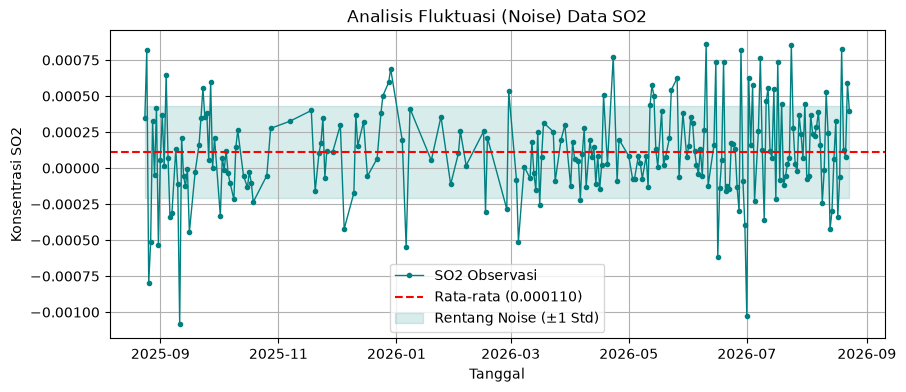

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/csv/SO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['SO2']).copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])

mean_val = df_clean['SO2'].mean()
std_val = df_clean['SO2'].std()
cv_val = (std_val / mean_val) * 100

print(f"Rata-rata SO2 : {mean_val:.6f}")
print(f"Standar Deviasi SO2 : {std_val:.6f}")
print(f"Koefisien Variasi (CV) SO2 : {cv_val:.2f}%")

# Visualisasi Fluktuasi / Noise Data SO2
plt.figure(figsize=(10, 4))
plt.plot(df_clean['date'], df_clean['SO2'], marker='o', color='teal', linewidth=1, markersize=3, label='SO2 Observasi')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Rata-rata ({mean_val:.6f})')
plt.fill_between(df_clean['date'], mean_val - std_val, mean_val + std_val, color='teal', alpha=0.15, label=f'Rentang Noise (±1 Std)')
plt.title('Analisis Fluktuasi (Noise) Data SO2')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi SO2')
plt.legend()
plt.grid(True)
plt.show()

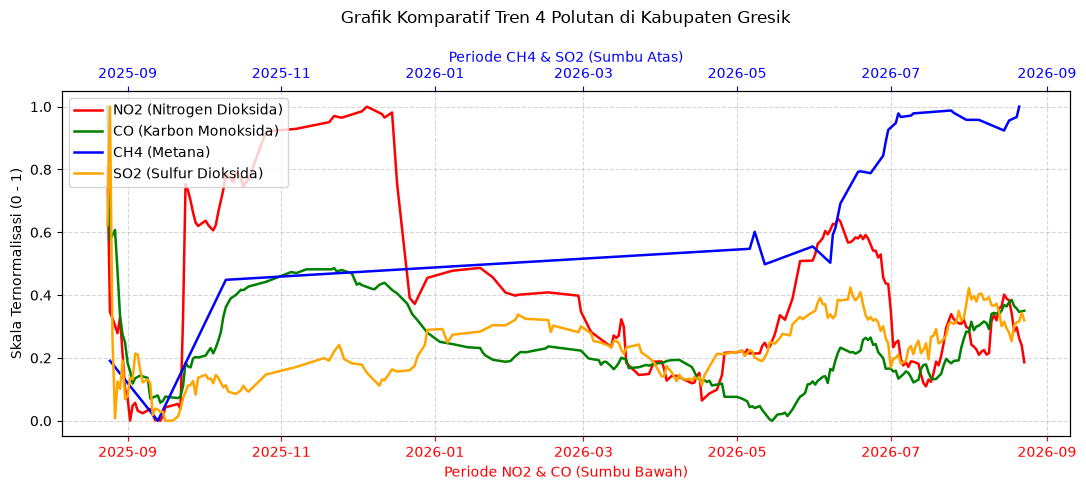

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data 4 Polutan
df_no2 = pd.read_csv("../data/csv/NO2_gresik_timeseries.csv").dropna(subset=['NO2'])
df_co  = pd.read_csv("../data/csv/CO_gresik_timeseries.csv").dropna(subset=['CO'])
df_ch4 = pd.read_csv("../data/csv/CH4_gresik_timeseries.csv").dropna(subset=['CH4'])
df_so2 = pd.read_csv("../data/csv/SO2_gresik_timeseries.csv").dropna(subset=['SO2'])

df_no2['date'] = pd.to_datetime(df_no2['date'])
df_co['date']  = pd.to_datetime(df_co['date'])
df_ch4['date'] = pd.to_datetime(df_ch4['date'])
df_so2['date'] = pd.to_datetime(df_so2['date'])

# 2. Smooth data dengan 30-day moving average (seperti Copernicus)
df_no2['NO2_smooth'] = df_no2['NO2'].rolling(window=30, min_periods=1).mean()
df_co['CO_smooth']   = df_co['CO'].rolling(window=30, min_periods=1).mean()
df_ch4['CH4_smooth'] = df_ch4['CH4'].rolling(window=30, min_periods=1).mean()
df_so2['SO2_smooth'] = df_so2['SO2'].rolling(window=30, min_periods=1).mean()

# 3. Normalisasi Min-Max (0 - 1)
for df, col in [(df_no2, 'NO2_smooth'), (df_co, 'CO_smooth'), (df_ch4, 'CH4_smooth'), (df_so2, 'SO2_smooth')]:
    df[col + '_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# 4. Figure Dual X-Axis (Gaya Copernicus twiny())
fig, ax1 = plt.subplots(figsize=(11, 5), dpi=100)

# Sumbu Bawah: NO2 (Merah) & CO (Hijau)
(line1,) = ax1.plot(df_no2['date'], df_no2['NO2_smooth_norm'], color="r", label="NO2 (Nitrogen Dioksida)", linewidth=1.8)
(line2,) = ax1.plot(df_co['date'],  df_co['CO_smooth_norm'],   color="g", label="CO (Karbon Monoksida)", linewidth=1.8)

ax1.set_xlabel("Periode NO2 & CO (Sumbu Bawah)", color='r', fontsize=10)
ax1.set_ylabel("Skala Ternormalisasi (0 - 1)")
ax1.xaxis.label.set_color("r")
ax1.tick_params(axis="x", colors="r")
ax1.grid(True, linestyle='--', alpha=0.5)

# Sumbu Atas: CH4 (Biru) & SO2 (Oranye)
ax2 = ax1.twiny()
(line3,) = ax2.plot(df_ch4['date'], df_ch4['CH4_smooth_norm'], color="b", label="CH4 (Metana)", linewidth=1.8)
(line4,) = ax2.plot(df_so2['date'], df_so2['SO2_smooth_norm'], color="orange", label="SO2 (Sulfur Dioksida)", linewidth=1.8)

ax2.set_xlabel("Periode CH4 & SO2 (Sumbu Atas)", color='b', fontsize=10)
ax2.xaxis.label.set_color("b")
ax2.tick_params(axis="x", colors="b")

# Combine Legend
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Grafik Komparatif Tren 4 Polutan di Kabupaten Gresik", pad=20)
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
from IPython.display import display

# ============================================================
# 1. Load data
# ============================================================

df = pd.read_excel(
    "../data/excel/polutan_gresik_clean.xlsx",
    sheet_name="CH4_Clean"
)


# ============================================================
# 2. Buat header "Unnamed" terlihat kosong
#    tetapi tetap unik secara internal
# ============================================================

new_columns = []

for i, col in enumerate(df.columns):
    if str(col).startswith("Unnamed:"):
        new_columns.append("\u200b" * (i + 1))
    else:
        new_columns.append(col)

df.columns = new_columns


# ============================================================
# 3. Warna statistik
# ============================================================

warna_statistik = {
    "min": "#092328",          # biru terang
    "max": "#12544F",          # hijau terang
    "mean": "#2A835F",         # kuning terang
    "median": "#FFD0B5",       # orange terang
    "variansi": "#C8F7C5 ",     # ungu terang
    "std deviasi": "#2A835F",  # hijau muda
    "skewness": "#FFBABA",     # merah muda
    "kurtosis": "#8BBB92",     # ungu muda
    "keruncingan": "#D8C7FF"
}


# ============================================================
# 4. Highlight hanya SEL statistik + NILAINYA
# ============================================================

def highlight_statistik(row):

    styles = [""] * len(row)

    for i, value in enumerate(row):

        if pd.isna(value):
            continue

        teks = str(value).strip().lower()

        # Apakah cell ini berisi nama statistik?
        if teks in warna_statistik:

            warna = warna_statistik[teks]

            # Warnai cell nama statistik
            styles[i] = (
                f"background-color: {warna}; "
                f"font-weight: bold; "
                f"color: #222;"
            )

            # Warnai cell tepat di sebelah kanan
            if i + 1 < len(row):
                styles[i + 1] = (
                    f"background-color: {warna}; "
                    f"font-weight: bold; "
                    f"color: #222;"
                )

    return styles


# ============================================================
# 5. Tampilkan tabel
# ============================================================

display(
    df.style
      .format(precision=2, na_rep="")
      .set_properties(**{
          "text-align": "center",
          "vertical-align": "middle"
      })
      .apply(highlight_statistik, axis=1)
      .set_caption("Data Polusi Udara - CH₄ Gresik")
)

,date,CH4,​​​,​​​​,​​​​​,​​​​​​,​​​​​​​,​​​​​​​​,​​​​​​​​​,pangkat 2 selisih,jumlah pangkat 2 selisih,pangkat 3 selisih,jumlah pangkat 3 selisih,pangkat 4 selisih,jumlah pangkat 4 selisih
0,2025-08-25,1867.29,,min,1854.82,jumlah baris data,31.00,,,653.17,9044.69,-3.19,-17.18,4.69,74.13
1,2025-09-13,1854.82,,max,1923.13,jumlah total data,58678.25,,,1445.75,,-10.50,,23.00,
2,2025-10-10,1905.00,,mean,1892.85,,,,,147.72,,0.34,,0.24,
3,2026-05-06,1888.60,,median,1895.63,,,,,18.07,,-0.01,,0.00,
4,2026-05-08,1887.77,,variansi,301.49,,,,,25.80,,-0.03,,0.01,
5,2026-05-12,1860.44,,std deviasi,17.36,,,,,1050.09,,-6.50,,12.13,
6,2026-05-31,1890.28,,kemiringan skewnes,-0.61,,,,,6.58,,-0.00,,0.00,
7,2026-06-07,1865.63,,keruncingan kurtosis,-0.31,,,,,740.52,,-3.85,,6.03,
8,2026-06-08,1903.68,,,,,,,,117.27,,0.24,,0.15,
9,2026-06-09,1887.13,,,,,,,,32.72,,-0.04,,0.01,
